In [1]:
from sympy import *

In [2]:
Y, X, z, t = symbols('Y X z t')

In [3]:
eq = (z**3 + 2*z**2 + 2*z + 1)*Y - 10/z - 1/(z**2+1)

In [4]:
solve(eq, Y)

[(10*z**2 + z + 10)/(z*(z**5 + 2*z**4 + 3*z**3 + 3*z**2 + 2*z + 1))]

In [5]:
inverse_laplace_transform((10*z**2 + z + 10)/(z*(z**5 + 2*z**4 + 3*z**3 + 3*z**2 + 2*z + 1)), z,t)

(-sin(t)/2 - cos(t)/2)*Heaviside(t) + 10*Heaviside(t) - 19*exp(-t)*Heaviside(t)/2 - 6*sqrt(3)*exp(-t/2)*sin(sqrt(3)*t/2)*Heaviside(t)

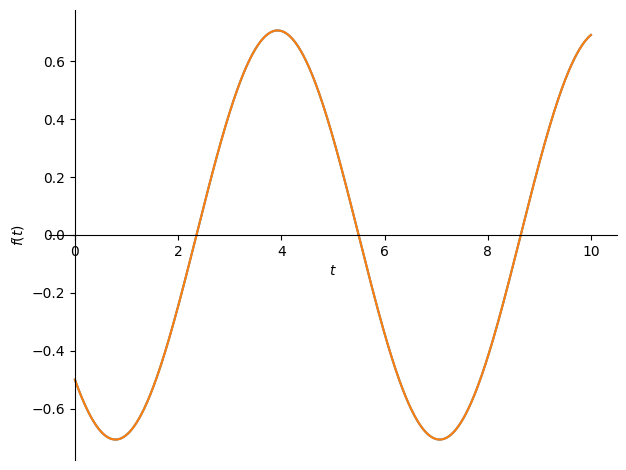

In [6]:
f1 = ((-sin(t)/2) - (cos(t)/2))
f2 = (-sqrt(2)/2)*sin(t + pi/4)
plot(f1, f2, (t, 0, 10))

### Series de fourier para ecuaciones 2-Perdiodicas

In [7]:
sf = fourier_series(t, (t, -pi, pi))   #2L es el perido 
sf

FourierSeries(t, (t, -pi, pi), (0, SeqFormula(0, (_k, 1, oo)), SeqFormula(Piecewise((-2*pi*cos(_n*pi)/_n + 2*sin(_n*pi)/_n**2, (_n > -oo) & (_n < oo) & Ne(_n, 0)), (0, True))*sin(_n*t)/pi, (_n, 1, oo))))

In [8]:
s1 = sf.truncate(3)
s2 = sf.truncate(10)
s3 = sf.truncate(300)
s4 = sf.truncate(1000)
s1

2*sin(t) - sin(2*t) + 2*sin(3*t)/3

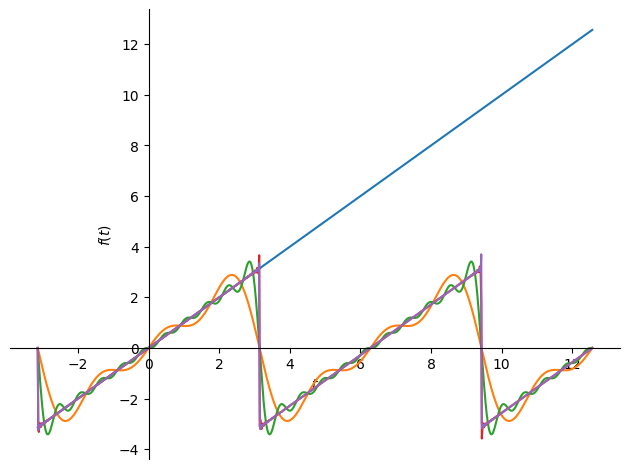

In [9]:
plot(t, s1, s2, s3, s4, (t, -pi, 4*pi))

#### Para ecuaciones diferenciales, se coge la función de fourier

In [10]:
# LA funcion tiene que ser asintoticamente estable, solo podemos sacar el régimen estacionario.

In [11]:
def T(z):
    return 1/(z**2+2*z+2)

In [12]:
T(I) # I para los numeros imaginarios

(1 - 2*I)/5

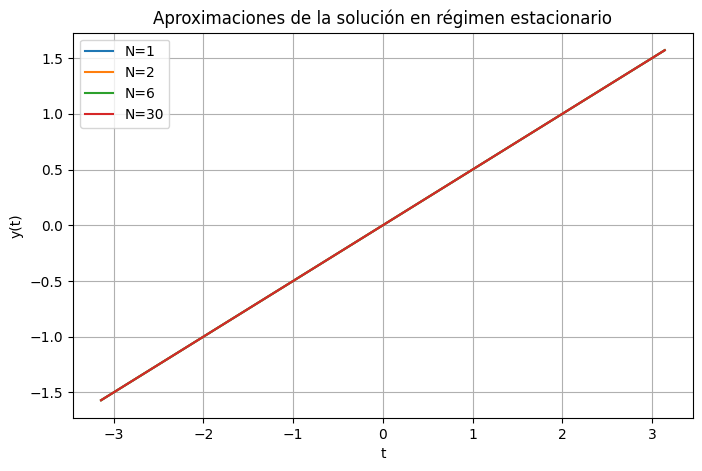

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

def fourier_solution(N, L, f_t):
    t, s, n = sp.symbols('t s n', real=True)
    
    # Definir la función de transferencia
    T_s = 1 / (s**2 + 2*s + 2)
    
    # Calcular coeficientes de Fourier
    a_0 = (1 / L) * sp.integrate(f_t, (t, -L, L))
    a_n = (1 / L) * sp.integrate(f_t * sp.cos(n * sp.pi * t / L), (t, -L, L))
    b_n = (1 / L) * sp.integrate(f_t * sp.sin(n * sp.pi * t / L), (t, -L, L))
    
    # Solución en régimen estacionario según la imagen
    y_t = a_0 / 2 * T_s.subs(s, 0)
    for k in range(1, N+1):
        T_k = T_s.subs(s, sp.I * k * sp.pi / L)
        magnitude = sp.simplify(sp.Abs(T_k))
        phase = sp.simplify(sp.arg(T_k))
        y_t += magnitude * (a_n.subs(n, k) * sp.cos(k * sp.pi * t / L + phase) + b_n.subs(n, k) * sp.sin(k * sp.pi * t / L))
    
    return y_t

def plot_solution(N_values, L, f_t):
    t_sym = sp.symbols('t')
    t_vals = np.linspace(-np.pi, np.pi, 400)
    
    plt.figure(figsize=(8, 5))
    
    for N in N_values:
        y_t_expr = fourier_solution(N, L, f_t)
        y_func = sp.lambdify(t_sym, y_t_expr, 'numpy')
        y_vals = y_func(t_vals)
        plt.plot(t_vals, y_vals, label=f'N={N}')
    
    plt.xlabel('t')
    plt.ylabel('y(t)')
    plt.title('Aproximaciones de la solución en régimen estacionario')
    plt.legend()
    plt.grid()
    plt.show()

L = float(input("Ingrese el período L: "))
t = sp.symbols('t')
f_t = sp.sympify(input("Ingrese la función f(t): "))
N_values = [1, 2, 6, 30]  # Valores de N como en la imagen
plot_solution(N_values, L, f_t)

In [ ]:
result = solve([z**X-6-3*X-8*Y,z*Y+2+3*Y+X],[X,Y])

In [ ]:
result

[((-2*log(z) - LambertW(-(z + 3)*log(z)/(z**2*(3*z + 1))))/log(z),
  LambertW(-(z + 3)*log(z)/(z**2*(3*z + 1)))/((z + 3)*log(z)))]